<a href="https://colab.research.google.com/github/AbishekPokhrel/AbishekPokhrel/blob/main/Week3_SelfAttention_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Self-Attention and Transformers

## Live Coding Activity (Google Colab)

This activity connects the Week 2 pipeline—text to tokens, token IDs, and embeddings—to the self-attention mechanism used by Transformers.

### Objectives

- Implement scaled dot-product attention from scratch.
- Use PyTorch tensors for matrix operations.
- Visualize attention weights.
- Compare embeddings before and after attention.
- Verify the calculation with PyTorch's MultiheadAttention.

> This notebook uses a toy example. Its vectors are not trained language-model representations; they make the attention calculation visible.


## Setup

In [1]:
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
torch.set_printoptions(precision=3, sci_mode=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Section 1: Review Embeddings from Week 2

A token ID is an index. An embedding layer maps each ID to a learned dense vector. Self-attention then lets each token update its vector by gathering information from other tokens in the same sequence.


In [3]:
tokens = ["plants", "need", "sunlight", "and", "water"]
word_to_id = {word: index for index, word in enumerate(tokens)}
token_ids = torch.tensor([word_to_id[word] for word in tokens])

embedding_layer = nn.Embedding(num_embeddings=len(tokens), embedding_dim=8)
week2_embeddings = embedding_layer(token_ids)

print("Tokens:", tokens)
print("Token IDs:", token_ids.tolist())
print("Embedding shape:", tuple(week2_embeddings.shape))

# fill the code 1: print out the embedding for "plants"
print("Embedding for plants:", week2_embeddings[word_to_id["plants"]])

Tokens: ['plants', 'need', 'sunlight', 'and', 'water']
Token IDs: [0, 1, 2, 3, 4]
Embedding shape: (5, 8)
Embedding for plants: tensor([-0.837, -0.922,  1.811,  0.161,  0.367,  0.175,  1.385, -0.446],
       grad_fn=<SelectBackward0>)


**Quick discussion:** Why can a neural network perform calculations with an embedding vector but not with a raw word? Why are IDs only labels rather than meaningful quantities?

- **Raw words vs Embeddings:** Models can't do math on text strings directly. They need continuous vectors so they can actually run matrix multiplications, dot products, and gradient updates.
- **Why IDs are only labels:** Token IDs are just indices (like row numbers in a lookup table). If we passed the raw IDs directly into the layers, the model would treat them like actual magnitudes - thinking token 4 is 4x larger than token 1, or that 1 + 2 = 3, which makes no sense.

## Section 2: Create Toy Embeddings

The input is a matrix with one row per token and eight features per embedding.


In [4]:
sequence_length = 5
embedding_dim = 8
embeddings = torch.rand(sequence_length, embedding_dim, device=device)

print("embeddings.shape:", tuple(embeddings.shape))
print("Rows correspond to:", tokens)
print(embeddings.cpu())

embeddings.shape: (5, 8)
Rows correspond to: ['plants', 'need', 'sunlight', 'and', 'water']
tensor([[0.654, 0.034, 0.172, 0.334, 0.578, 0.060, 0.285, 0.201],
        [0.501, 0.314, 0.465, 0.161, 0.157, 0.208, 0.329, 0.105],
        [0.919, 0.401, 0.930, 0.656, 0.077, 0.846, 0.362, 0.308],
        [0.085, 0.003, 0.643, 0.391, 0.695, 0.090, 0.871, 0.133],
        [0.414, 0.604, 0.758, 0.904, 0.955, 0.104, 0.626, 0.285]])


## Section 3: Create Query, Key, and Value (Q, K, V)

Q, K, and V are different learned projections of the input embeddings:

- Query: what a token is looking for.
- Key: what a token offers for matching.
- Value: information a token contributes when attended to.

They are learned representations, not fixed linguistic categories.


In [5]:
attention_dim = 8
query_layer = nn.Linear(embedding_dim, attention_dim, bias=False).to(device)
key_layer = nn.Linear(embedding_dim, attention_dim, bias=False).to(device)
value_layer = nn.Linear(embedding_dim, attention_dim, bias=False).to(device)

Q = query_layer(embeddings)
K = key_layer(embeddings)
V = value_layer(embeddings)

print("Q shape:", tuple(Q.shape))
print("K shape:", tuple(K.shape))
print("V shape:", tuple(V.shape))

Q shape: (5, 8)
K shape: (5, 8)
V shape: (5, 8)


## Section 4: Compute Attention Scores

The matrix product Q multiplied by K transpose compares every query with every key. A row represents the query token; a column represents the candidate key token.


In [6]:
# fill the code 2: caculate the attention scores
attention_scores =torch.matmul(Q, K.T)
print("attention_scores.shape:", tuple(attention_scores.shape))
print("Raw QK transpose scores:")
print(attention_scores.cpu())

attention_scores.shape: (5, 5)
Raw QK transpose scores:
tensor([[-0.010, -0.035,  0.001,  0.065,  0.086],
        [-0.038, -0.041, -0.064,  0.022, -0.061],
        [-0.056, -0.042, -0.047,  0.067, -0.090],
        [-0.008, -0.027,  0.029, -0.037, -0.161],
        [ 0.049,  0.027,  0.055,  0.147,  0.064]], grad_fn=<MmBackward0>)


**Predict:** After softmax, what should the sum of every row in the attention matrix be?

Answer:Every row should sum to **1.0** because softmax converts the raw dot-product scores into a normalized probability distribution across all key tokens.

## Section 5: Scale and Normalize Scores

Scaled dot-product attention uses:

Attention(Q, K, V) = softmax(QK transpose / sqrt(d_k)) V

Scaling prevents large dot products from making softmax too peaked. Softmax converts each row to weights that sum to one.


In [7]:
scaled_scores = attention_scores / math.sqrt(attention_dim)
attention_weights = torch.softmax(scaled_scores, dim=-1)

print("attention_weights.shape:", tuple(attention_weights.shape))
print(attention_weights.cpu())
print("Row sums:", attention_weights.sum(dim=-1).cpu())

attention_weights.shape: (5, 5)
tensor([[0.198, 0.196, 0.198, 0.203, 0.205],
        [0.200, 0.200, 0.198, 0.204, 0.198],
        [0.198, 0.199, 0.199, 0.207, 0.196],
        [0.202, 0.201, 0.205, 0.200, 0.192],
        [0.199, 0.197, 0.199, 0.206, 0.200]], grad_fn=<SoftmaxBackward0>)
Row sums: tensor([1., 1., 1., 1., 1.], grad_fn=<SumBackward1>)


## Section 6: Aggregate the Values

Each output embedding is a weighted combination of all value vectors. It is a context-aware representation of the original token.


In [8]:
# fill the code 3: caculate the attention output
attention_output =torch.matmul(attention_weights, V)
print("attention_output.shape:", tuple(attention_output.shape))

for index, token in enumerate(tokens):
    print("\nToken:", token)
    print("Original embedding:", embeddings[index].detach().cpu())
    print("After attention:  ", attention_output[index].detach().cpu())

attention_output.shape: (5, 8)

Token: plants
Original embedding: tensor([0.654, 0.034, 0.172, 0.334, 0.578, 0.060, 0.285, 0.201])
After attention:   tensor([-0.411, -0.181, -0.360,  0.039,  0.324, -0.278, -0.166, -0.284])

Token: need
Original embedding: tensor([0.501, 0.314, 0.465, 0.161, 0.157, 0.208, 0.329, 0.105])
After attention:   tensor([-0.409, -0.179, -0.359,  0.038,  0.321, -0.278, -0.166, -0.283])

Token: sunlight
Original embedding: tensor([0.919, 0.401, 0.930, 0.656, 0.077, 0.846, 0.362, 0.308])
After attention:   tensor([-0.409, -0.179, -0.359,  0.038,  0.321, -0.277, -0.165, -0.284])

Token: and
Original embedding: tensor([0.085, 0.003, 0.643, 0.391, 0.695, 0.090, 0.871, 0.133])
After attention:   tensor([-0.407, -0.177, -0.360,  0.036,  0.319, -0.278, -0.168, -0.283])

Token: water
Original embedding: tensor([0.414, 0.604, 0.758, 0.904, 0.955, 0.104, 0.626, 0.285])
After attention:   tensor([-0.410, -0.180, -0.359,  0.039,  0.322, -0.278, -0.166, -0.284])


**Discuss:** Is attention permanent memory? Explain why it is better described as weighted aggregation for the current calculation.

Answer:Attention is not permanent memory. It is an on-the-fly weighted sum computed dynamically for the current forward pass. Permanent knowledge is stored in the model's static trained weights.

## Section 7: Visualize the Attention Matrix

Read a row from left to right. For example, the row for plants shows how much plants attends to every token, including itself.


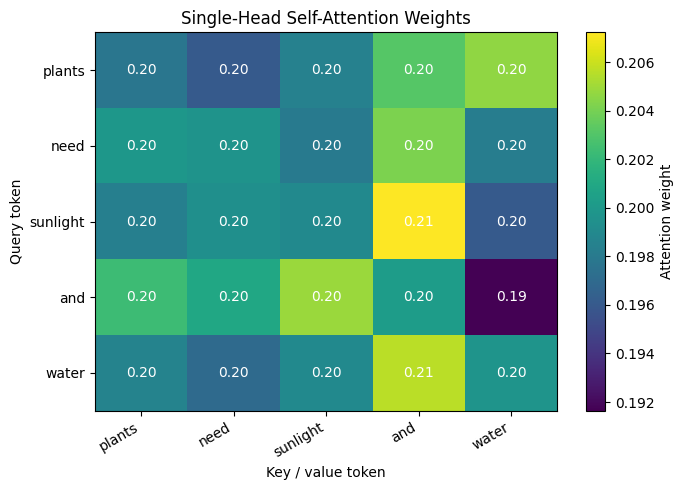

   plants attends most to: water
     need attends most to: and
 sunlight attends most to: and
      and attends most to: sunlight
    water attends most to: and


In [9]:
plt.figure(figsize=(7, 5))
plt.imshow(attention_weights.detach().cpu(), cmap="viridis", aspect="auto")
plt.colorbar(label="Attention weight")
plt.xticks(range(sequence_length), tokens, rotation=30, ha="right")
plt.yticks(range(sequence_length), tokens)
plt.xlabel("Key / value token")
plt.ylabel("Query token")
plt.title("Single-Head Self-Attention Weights")

for i in range(sequence_length):
    for j in range(sequence_length):
        weight = attention_weights[i, j].item()
        color = "white" if weight < 0.35 else "black"
        plt.text(j, i, f"{weight:.2f}", ha="center", va="center", color=color)

plt.tight_layout()
plt.show()

for query_token, key_id in zip(tokens, attention_weights.argmax(dim=-1).cpu().tolist()):
    print(f"{query_token:>9} attends most to: {tokens[key_id]}")

## Section 8: Compare with PyTorch MultiheadAttention

We use one attention head and copy the manual Q, K, and V projection weights into PyTorch's module. The output projection is set to the identity matrix. The manual and module outputs should match except for tiny floating-point differences.


In [11]:
pytorch_attention = nn.MultiheadAttention(
    embed_dim=embedding_dim,
    num_heads=1,
    bias=False,
    batch_first=True,
    dropout=0.0
).to(device)

with torch.no_grad():
    pytorch_attention.in_proj_weight.copy_(
        torch.cat([query_layer.weight, key_layer.weight, value_layer.weight], dim=0)
    )
    pytorch_attention.out_proj.weight.copy_(torch.eye(embedding_dim, device=device))

attention_input = embeddings.unsqueeze(0)
module_output, module_weights = pytorch_attention(
    attention_input, attention_input, attention_input,
    need_weights=True, average_attn_weights=False
)
module_output = module_output.squeeze(0)
module_weights = module_weights.squeeze(0).squeeze(0)

print("Manual output shape:", tuple(attention_output.shape))
print("Module output shape:", tuple(module_output.shape))
print("Outputs match:", torch.allclose(attention_output, module_output, atol=1e-6))
print("Weights match:", torch.allclose(attention_weights, module_weights, atol=1e-6))
print("Maximum output difference:", (attention_output - module_output).abs().max().item())

Manual output shape: (5, 8)
Module output shape: (5, 8)
Outputs match: True
Weights match: True
Maximum output difference: 2.9802322387695312e-08


In [12]:
# Optional extension: 2 heads with embed_dim=8
multihead_2 = nn.MultiheadAttention(
    embed_dim=8,
    num_heads=2,
    bias=False,
    batch_first=True
).to(device)

out_2, weights_2 = multihead_2(
    attention_input, attention_input, attention_input,
    need_weights=True, average_attn_weights=False
)

print("Weights shape (batch, heads, seq, seq):", tuple(weights_2.shape))
print("Squeezed weights shape:", tuple(weights_2.squeeze(0).shape))

Weights shape (batch, heads, seq, seq): (1, 2, 5, 5)
Squeezed weights shape: (2, 5, 5)


## Exit Ticket

Answer in a Markdown cell:

1. What are the shapes of Q, K, V, QK transpose, attention weights, and the final attention output?
2. What does one row of the attention-weight matrix represent?
3. Why do we divide by square root of d_k before softmax?
4. How is an attention output embedding different from the original embedding?
5. Why does a Transformer need positional encoding?

## Instructor Notes: Common Misconceptions

- **Attention is not memory.** It is a weighted aggregation mechanism.
- **Queries, keys, and values are learned representations**, not fixed linguistic concepts.
- **Multi-head attention does not simply repeat the same computation.** Each head learns separate projections and may capture different relationships.
- **Self-attention alone is permutation invariant.** Positional encoding supplies token-order information.

### Optional extension

Change the module to two heads while keeping the embedding dimension at eight. Inspect the returned attention-weight shape and explain why each head has its own attention pattern.

## Key takeaway

Self-attention transforms each token embedding into a context-aware vector by comparing queries and keys, normalizing scores into weights, and aggregating values.


## Exit Ticket Answers

1. **Tensor shapes:**
   - $Q, K, V$: `(5, 8)` [batch-less: sequence length 5, attention dim 8]
   - $QK^T$: `(5, 5)` [sequence length by sequence length]
   - Attention weights: `(5, 5)`
   - Final attention output: `(5, 8)`

2. **What one row of the attention-weight matrix represents:**
   - One row represents a single query token's attention distribution over all tokens in the sequence. It shows how much weight (focus) that token places on every other token (and itself) when forming its new representation.

3. **Why divide by $\sqrt{d_k}$ before softmax:**
   - When the key dimension $d_k$ is large, the dot products can grow quite large in magnitude. This pushes the softmax function into regions with very small gradients, causing vanishing gradients during backpropagation. Dividing by $\sqrt{d_k}$ keeps the variance around 1 and stabilizes training.

4. **Attention output vs. original embedding:**
   - The original embedding only contains the static, independent meaning of a single word in isolation. The attention output is a context-aware vector: it blends information from all surrounding tokens in the sequence based on their relevance to that word.

5. **Why a Transformer needs positional encoding:**
   - Self-attention operations are permutation-invariant—the dot products and weighted sums treat the tokens as an unordered set. Without positional encodings, the model has no way to tell word order apart (for example, "plants need water" vs. "water need plants").

---

### Optional Extension Note
If we switch to num_heads=2 with embed_dim=8, the head dimension becomes d_k = 8 / 2 = 4.

The returned attention weight shape is (2, 5, 5), giving one 5x5 matrix for each head.

Each head has its own attention pattern because each head uses separate learned projection weights. That lets one head learn syntactic relationships (like subject-verb alignment) while the other tracks semantic context.